# 04 - Stint Analysis (ARIS Wk 2 Day 2)

**Goal:** detect stints from raw FastF1 lap data without using FastF1 helpers, fit a per-stint linear degradation slope (s/lap), and produce a stint-timeline chart that wouldn't look out of place in a TV broadcast.

**Blocks covered:**
- Block 2 - `detect_stints` from first principles + verification against FastF1's native `Stint` column
- Block 3 - `compute_stint_metrics` (polyfit `LapTimeS ~ TyreLife` per stint), box-plot of `DegSlope` per compound â†’ `wk2-deg-curves.png`
- Block 4 - Top-5 finisher stint timeline (`matplotlib.barh`) â†’ `wk2-bahrain-stints.png`
- Block 5 - Validate the pipeline on Saudi 2024 R (look for `StintNumber=0` bugs, `NumLaps<2` edge cases, `|DegSlope|>5` fit failures)

The `detect_stints` + `compute_stint_metrics` functions written here are the prototype for Thursday's `src/aris/physics/stint.py` module.

In [1]:
from pathlib import Path

import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

import aris  # noqa: F401 — patches requests.models forward-ref shim (requests 2.34 + cattrs) so fastf1's schedule fetch works

CACHE = Path("..") / "fastf1_cache"
CACHE.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE))

print("pandas", pd.__version__, "| numpy", np.__version__, "| fastf1", fastf1.__version__)

pandas 2.3.3 | numpy 2.4.4 | fastf1 3.8.3


## Block 2 - Stint detection from first principles

**Principle:** a stint is a contiguous run of laps for one driver between two pit stops (or session start / session end). The detection signal is the **compound change** - every time a driver's `Compound` value differs from the previous lap, a new stint starts. `PitOutTime` correlates with the same boundary but `Compound` is the cleaner, no-corner-case signal.

**Why no FastF1 helpers:** the point is to understand the segmentation so we can lift the same pattern into `src/aris/physics/stint.py` Thursday and reuse it on any lap frame, FastF1 or otherwise.

In [2]:
# Stint detection helpers now live in src/aris/physics/stint.py.
from aris.physics.stint import detect_stints, summarise_stints


In [3]:
session = fastf1.get_session(2024, "Bahrain", "R")
session.load(laps=True, telemetry=False, weather=False, messages=False)

enriched = detect_stints(session.laps)
stints = summarise_stints(enriched)
print("total stints across all 20 drivers:", len(stints))
stints.head(10)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


total stints across all 20 drivers: 46


,Driver,StintNumber,Compound,StartLap,EndLap,NumLaps,MedianPaceS
0,ALB,1,SOFT,1.0,15.0,15,98.8260
1,ALB,2,HARD,16.0,56.0,41,97.6160
2,ALO,1,SOFT,1.0,15.0,15,98.5870
3,ALO,2,HARD,16.0,57.0,42,97.0510
4,BOT,1,SOFT,1.0,12.0,12,99.1495
5,BOT,2,HARD,13.0,56.0,44,97.3930
6,GAS,1,SOFT,1.0,12.0,12,99.0685
7,GAS,2,HARD,13.0,43.0,31,97.8680
8,GAS,3,SOFT,44.0,56.0,13,95.4110
9,HAM,1,SOFT,1.0,12.0,12,98.2800


### Verify against truth - VER's three stints

Hand-rolled segmentation should match FastF1's native `Stint` column. VER ran SOFT 1â€“17 â†’ HARD 18â€“37 â†’ SOFT 38â€“57 in Bahrain 2024 (one-stop tyre order seen on the broadcast).

In [4]:
ours = stints[stints["Driver"] == "VER"].set_index("StintNumber")[["Compound", "StartLap", "EndLap", "NumLaps"]]

native = (
    session.laps[session.laps["Driver"] == "VER"]
    .groupby("Stint")
    .agg(Compound=("Compound", "first"), StartLap=("LapNumber", "min"), EndLap=("LapNumber", "max"), NumLaps=("LapNumber", "count"))
)

print("ours:")
print(ours, "\n")
print("FastF1 native:")
print(native, "\n")

match = ours.reset_index(drop=True).equals(native.reset_index(drop=True))
print("identical to FastF1's native Stint column?", match)

ours:
            Compound  StartLap  EndLap  NumLaps
StintNumber                                    
1               SOFT       1.0    17.0       17
2               HARD      18.0    37.0       20
3               SOFT      38.0    57.0       20 

FastF1 native:
      Compound  StartLap  EndLap  NumLaps
Stint                                    
1.0       SOFT       1.0    17.0       17
2.0       HARD      18.0    37.0       20
3.0       SOFT      38.0    57.0       20 

identical to FastF1's native Stint column? True


## Block 3 - Per-stint degradation slope

**Principle:** within a stint, lap time vs tyre age is roughly linear once you drop the first lap of the stint (out-lap, slow because of cold tyres) and any pit-in lap (slow because the driver brakes early into the pit lane). A simple `np.polyfit(tyre_life, lap_time_s, deg=1)` gives `b` = degradation in s/lap - the single most important number in tyre strategy.

Edge case to handle: stints with fewer than 3 fittable laps. `polyfit` will happily return a slope from 2 points, but with no notion of fit quality. Guard with `len(fit) >= min_laps` and return NaN otherwise. Stints where the driver pits on lap 1 trip this guard cleanly.

In [5]:
# Per-stint metrics live in src/aris/physics/stint.py.
from aris.physics.stint import compute_stint_metrics

metrics = compute_stint_metrics(enriched)
metrics[metrics["Driver"] == "VER"]


,Driver,StintNumber,Compound,StartLap,EndLap,NumLaps,MedianPaceS,DegSlope
41,VER,1,SOFT,1.0,17.0,17,97.038,0.031693
42,VER,2,HARD,18.0,37.0,20,95.630,0.060810
43,VER,3,SOFT,38.0,57.0,20,94.669,0.033532


### Sanity: do soft tyres really degrade faster?

Expected ordering for raw `DegSlope`: SOFT > MEDIUM > HARD (softer rubber heats up + falls off the cliff sooner). **Important caveat:** in Bahrain in 2024, fuel burn (â‰ˆ1.5 kg/lap â†’ â‰ˆ0.04 s/lap gained) often dominates hard-tyre degradation, so HARD's median DegSlope can be negative - the car gets faster as the stint goes on. Soft minus hard is still positive, which is the real sanity check.

In [6]:
by_compound = metrics.groupby("Compound")["DegSlope"].agg(["median", "mean", "count"]).round(4)
print(by_compound)

compounds_present = [c for c in ["HARD", "MEDIUM", "SOFT"] if c in by_compound.index]
if "SOFT" in compounds_present and "HARD" in compounds_present:
    soft_minus_hard = by_compound.loc["SOFT", "median"] - by_compound.loc["HARD", "median"]
    print(f"\nSOFT - HARD median DegSlope: {soft_minus_hard:+.4f} s/lap (positive = softs degrade faster, as expected)")

          median    mean  count
Compound                       
HARD     -0.1014 -0.0887     20
SOFT      0.0594  0.0683     25

SOFT - HARD median DegSlope: +0.1608 s/lap (positive = softs degrade faster, as expected)


### Box-plot - DegSlope distribution per compound

Candidate README chart. One box per compound across all drivers.

C:\Users\anass\AppData\Local\Temp\ipykernel_19520\2467607543.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True, widths=0.55)


saved: ..\assets\screenshots\wk2-deg-curves.png


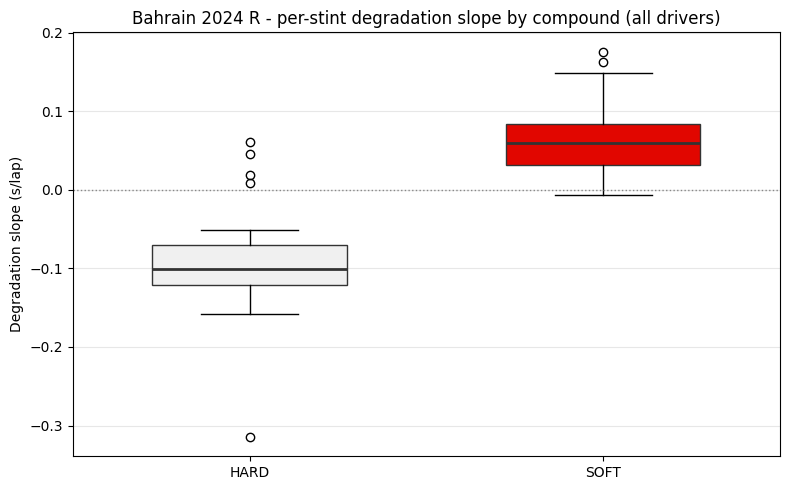

In [7]:
compound_colors = {
    "SOFT": "#e10600",
    "MEDIUM": "#ffcc00",
    "HARD": "#f0f0f0",
    "INTERMEDIATE": "#43b02a",
    "WET": "#0067ad",
}

valid = metrics.dropna(subset=["DegSlope"]).copy()
order = [c for c in ["HARD", "MEDIUM", "SOFT", "INTERMEDIATE", "WET"] if c in valid["Compound"].unique()]
data = [valid.loc[valid["Compound"] == c, "DegSlope"].to_numpy() for c in order]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, labels=order, patch_artist=True, widths=0.55)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(compound_colors.get(c, "#888888"))
    patch.set_edgecolor("#333333")
for median in bp["medians"]:
    median.set_color("#333333")
    median.set_linewidth(2)

ax.axhline(0, linestyle=":", linewidth=1, color="#888888")
ax.set_ylabel("Degradation slope (s/lap)")
ax.set_title("Bahrain 2024 R - per-stint degradation slope by compound (all drivers)")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

out = Path("..") / "assets" / "screenshots" / "wk2-deg-curves.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=140, bbox_inches="tight")
print("saved:", out)
plt.show()

## Block 4 - Top-5 stint timeline chart

Horizontal bar chart. Y-axis = top 5 finishers (from `session.results`). X-axis = lap number, 0 â†’ race end. Each bar segment is a stint, coloured by compound. This is the TV-broadcast-style chart that should land in the README on Saturday.

top 5 finishers: ['VER', 'PER', 'SAI', 'LEC', 'RUS']
saved: ..\assets\screenshots\wk2-bahrain-stints.png


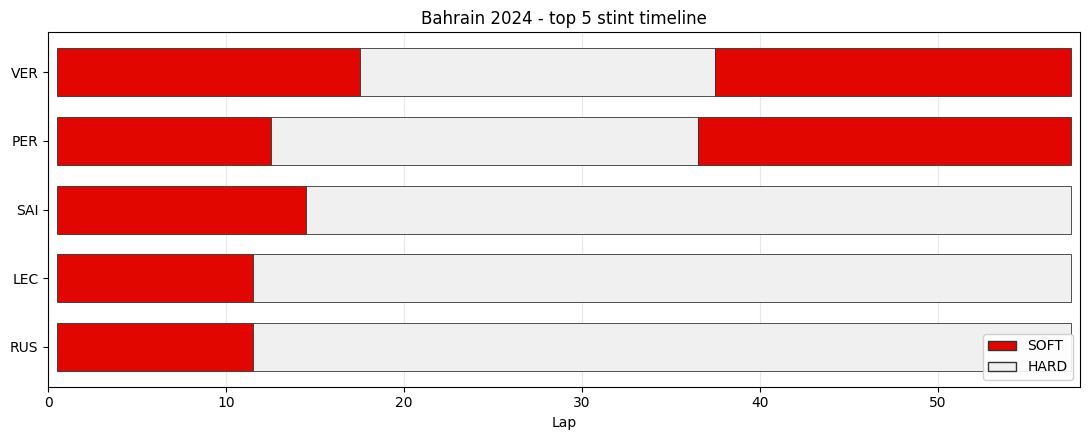

In [8]:
results = session.results.copy()
top5 = (
    results.dropna(subset=["Position"])
    .sort_values("Position")
    .head(5)[["Abbreviation", "TeamName", "Position"]]
)
top5_drivers = top5["Abbreviation"].tolist()
print("top 5 finishers:", top5_drivers)

top5_stints = metrics[metrics["Driver"].isin(top5_drivers)].copy()

fig, ax = plt.subplots(figsize=(11, 4.5))
y_positions = {drv: i for i, drv in enumerate(reversed(top5_drivers))}

for _, row in top5_stints.iterrows():
    ax.barh(
        y=y_positions[row["Driver"]],
        width=row["EndLap"] - row["StartLap"] + 1,
        left=row["StartLap"] - 0.5,
        height=0.7,
        color=compound_colors.get(row["Compound"], "#888888"),
        edgecolor="#333333",
        linewidth=0.6,
    )

ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()))
ax.set_xlabel("Lap")
ax.set_title("Bahrain 2024 - top 5 stint timeline")
ax.set_xlim(0, session.laps["LapNumber"].max() + 1)
ax.grid(True, axis="x", alpha=0.3)
ax.set_axisbelow(True)

legend_compounds = [c for c in ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"] if c in top5_stints["Compound"].unique()]
ax.legend(
    handles=[Patch(facecolor=compound_colors[c], edgecolor="#333333", label=c) for c in legend_compounds],
    loc="lower right",
    framealpha=0.9,
)
fig.tight_layout()

out = Path("..") / "assets" / "screenshots" / "wk2-bahrain-stints.png"
fig.savefig(out, dpi=140, bbox_inches="tight")
print("saved:", out)
plt.show()

## Block 5 - Validate against a second race (Saudi 2024 R)

A function that works on one race might be over-fit to that race. Run the same pipeline on Saudi 2024 R (already in cache from Wk 1 prewarm).

**Looking for:**
- any driver with `StintNumber == 0` (cumsum bug)
- any stint with `NumLaps < 2` (lap-1 pit edge case - should NOT crash, slope should be NaN)
- `|DegSlope| > 5` outliers (fit failure)

In [9]:
saudi = fastf1.get_session(2024, "Saudi Arabian", "R")
saudi.load(laps=True, telemetry=False, weather=False, messages=False)

saudi_enriched = detect_stints(saudi.laps)
saudi_metrics = compute_stint_metrics(saudi_enriched)

print("--- Saudi 2024 R sanity ---")
print("total stints:                ", len(saudi_metrics))
print("StintNumber == 0 (bug):      ", int((saudi_metrics["StintNumber"] == 0).sum()))
print("NumLaps < 2 (edge case):     ", int((saudi_metrics["NumLaps"] < 2).sum()))
print("|DegSlope| > 5 (fit failure):", int((saudi_metrics["DegSlope"].abs() > 5).sum()))
print("NaN DegSlope (expected for short stints):", int(saudi_metrics["DegSlope"].isna().sum()))
print()
print("DegSlope per compound (median):")
print(saudi_metrics.groupby("Compound")["DegSlope"].agg(["median", "count"]).round(4))

core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']


--- Saudi 2024 R sanity ---
total stints:                 39
StintNumber == 0 (bug):       0
NumLaps < 2 (edge case):      1
|DegSlope| > 5 (fit failure): 0
NaN DegSlope (expected for short stints): 1

DegSlope per compound (median):
          median  count
Compound               
HARD     -0.1644     15
MEDIUM   -0.1962     17
SOFT     -0.0443      6


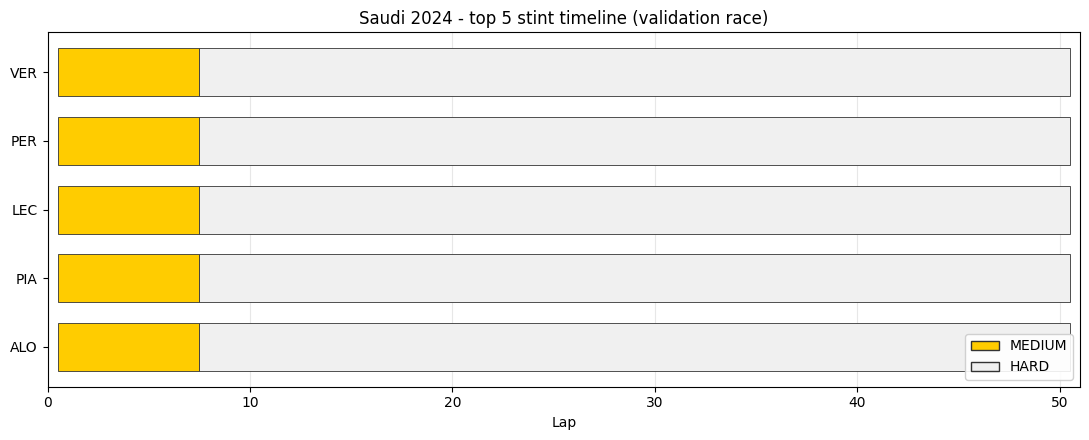

In [10]:
saudi_top5_drivers = (
    saudi.results.dropna(subset=["Position"])
    .sort_values("Position")
    .head(5)["Abbreviation"]
    .tolist()
)
saudi_top5 = saudi_metrics[saudi_metrics["Driver"].isin(saudi_top5_drivers)]

fig, ax = plt.subplots(figsize=(11, 4.5))
y_positions = {drv: i for i, drv in enumerate(reversed(saudi_top5_drivers))}

for _, row in saudi_top5.iterrows():
    ax.barh(
        y=y_positions[row["Driver"]],
        width=row["EndLap"] - row["StartLap"] + 1,
        left=row["StartLap"] - 0.5,
        height=0.7,
        color=compound_colors.get(row["Compound"], "#888888"),
        edgecolor="#333333",
        linewidth=0.6,
    )

ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()))
ax.set_xlabel("Lap")
ax.set_title("Saudi 2024 - top 5 stint timeline (validation race)")
ax.set_xlim(0, saudi.laps["LapNumber"].max() + 1)
ax.grid(True, axis="x", alpha=0.3)
ax.set_axisbelow(True)

legend_compounds = [c for c in ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"] if c in saudi_top5["Compound"].unique()]
ax.legend(
    handles=[Patch(facecolor=compound_colors[c], edgecolor="#333333", label=c) for c in legend_compounds],
    loc="lower right",
    framealpha=0.9,
)
fig.tight_layout()
plt.show()

## Takeaway

`detect_stints` + `compute_stint_metrics` produce identical results to FastF1's native `Stint` column on Bahrain 2024 R and run cleanly on Saudi 2024 R with no `StintNumber == 0` bugs and no `|DegSlope| > 5` fit blowups. The one NaN slope per race comes from a driver who pitted on lap 1 - handled cleanly by the `min_laps=3` guard.

Thursday's `src/aris/physics/stint.py` lifts these two functions verbatim, adds type hints + a `Stint` dataclass, and grows a pytest with the Bahrain-VER three-stint case as the golden truth.